In [12]:
import pandas as pd
import seaborn as sns
import pylab as plt

In [13]:
df=pd.read_csv('./multisweep_summary.csv')

<Axes: xlabel='e_q', ylabel='cover_95'>

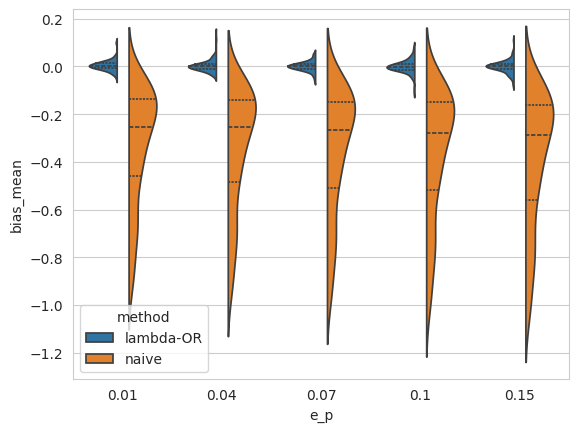

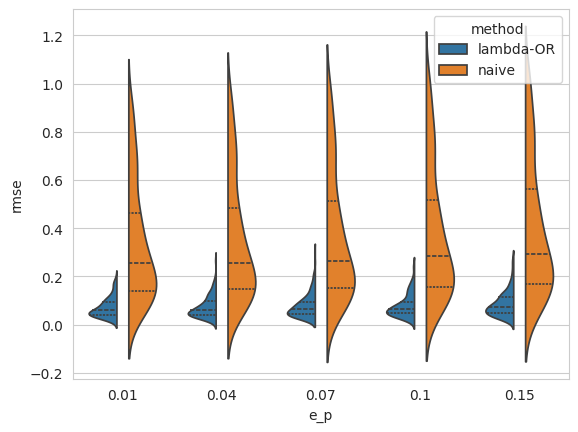

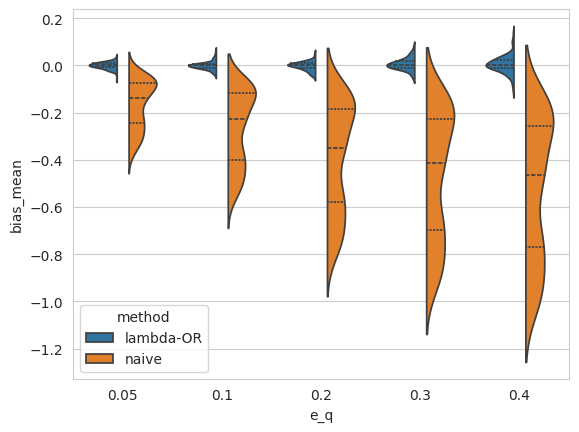

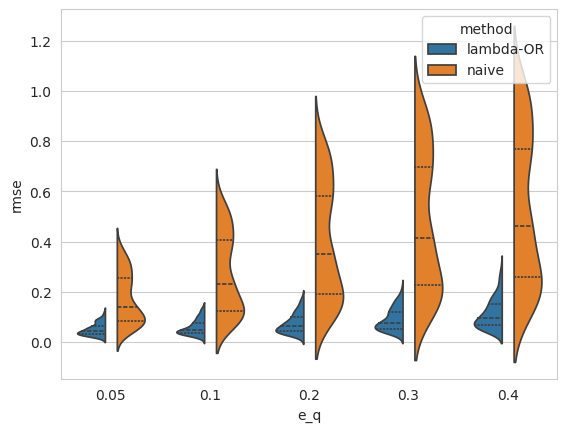

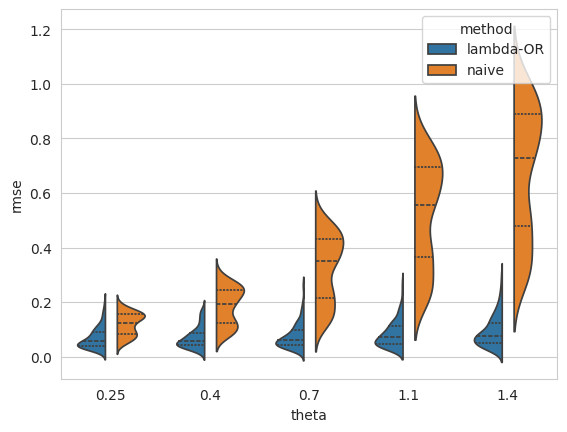

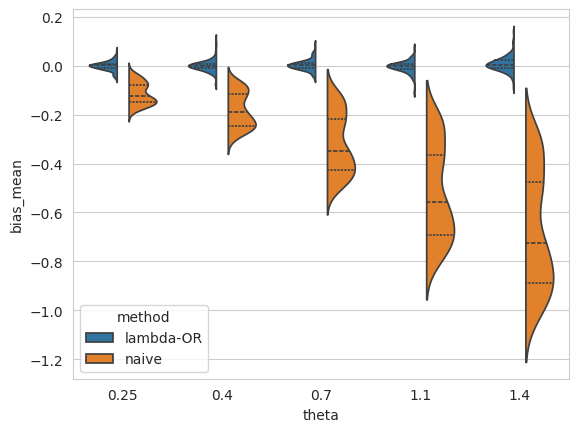

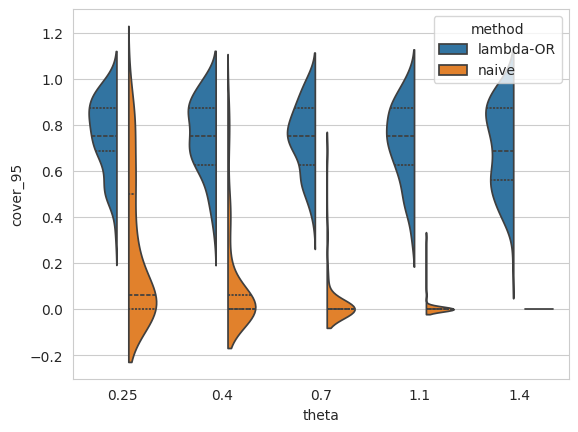

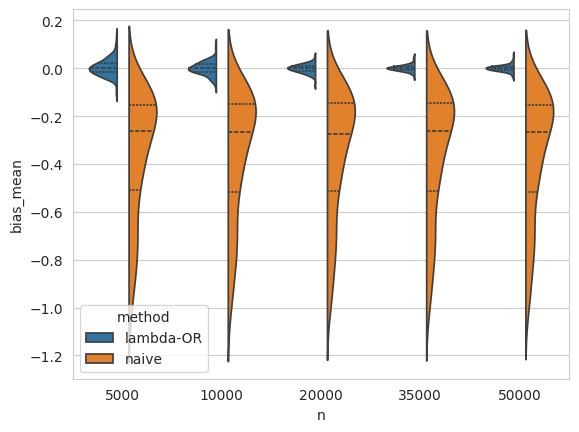

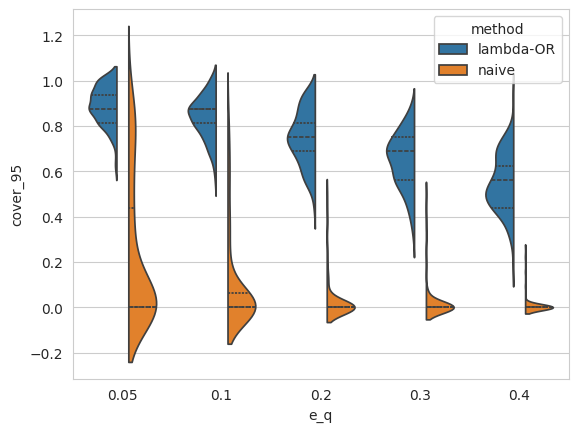

In [18]:
df['e_p']=1-df.p_sel
df['e_q']=1-df.q_sel
df=df.round(3)


plt.figure()

sns.violinplot(x='e_p',y='bias_mean',data=df, hue='method',split=True, inner="quart", gap=.3,density_norm='count')
plt.figure()
sns.violinplot(x='e_p',y='rmse',data=df, hue='method',split=True, inner="quart", gap=.3,density_norm='count')
plt.figure()
sns.violinplot(x='e_q',y='bias_mean',data=df, hue='method',split=True, inner="quart", gap=.3,density_norm='count')
plt.figure()
sns.violinplot(x='e_q',y='rmse',data=df, hue='method',split=True, inner="quart", gap=.3,density_norm='count')
plt.figure()
sns.violinplot(x='theta',y='rmse',data=df, hue='method',split=True, inner="quart", gap=.3,density_norm='count')
plt.figure()
sns.violinplot(x='theta',y='bias_mean',data=df, hue='method',split=True, inner="quart", gap=.3,density_norm='count')
plt.figure()
sns.violinplot(x='theta',y='cover_95',data=df, hue='method',split=True, inner="quart", gap=.3,density_norm='count')
plt.figure()
sns.violinplot(x='n',y='bias_mean',data=df, hue='method',split=True, inner="quart", gap=.3,density_norm='count')
plt.figure()
sns.violinplot(x='e_q',y='cover_95',data=df, hue='method',split=True, inner="quart", gap=.3,density_norm='count')




In [4]:
df

,method,p_sel,q_sel,n,theta,detK,bias_mean,bias_sd,rmse,cover_95,se_mean,feasible_rate,lam_median,e_p,e_q
0,lambda-OR,0.85,0.60,5000,0.25,0.45,-0.009,0.209,0.203,0.500,0.072,1.0,0.0,0.15,0.40
1,lambda-OR,0.85,0.60,5000,0.40,0.45,0.111,0.144,0.178,0.625,0.072,1.0,0.0,0.15,0.40
2,lambda-OR,0.85,0.60,5000,0.70,0.45,0.011,0.270,0.261,0.438,0.074,1.0,0.0,0.15,0.40
3,lambda-OR,0.85,0.60,5000,1.10,0.45,-0.037,0.277,0.271,0.438,0.077,1.0,0.0,0.15,0.40
4,lambda-OR,0.85,0.60,5000,1.40,0.45,-0.010,0.242,0.234,0.500,0.080,1.0,0.0,0.15,0.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1245,naive,0.99,0.95,50000,0.25,0.94,-0.040,0.019,0.044,0.562,0.021,1.0,0.0,0.01,0.05
1246,naive,0.99,0.95,50000,0.40,0.94,-0.071,0.016,0.072,0.000,0.021,1.0,0.0,0.01,0.05
1247,naive,0.99,0.95,50000,0.70,0.94,-0.126,0.022,0.128,0.000,0.021,1.0,0.0,0.01,0.05
1248,naive,0.99,0.95,50000,1.10,0.94,-0.210,0.025,0.211,0.000,0.022,1.0,0.0,0.01,0.05


In [5]:
import tikzplotlib
#df_,_ = roundk(df,10)
#df_.e_p.value_counts()

In [11]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# palette (grey, green)
palette = ['#9e9e9e', '#4caf50']

# ---- map method names to manuscript labels ----
# Adjust the left-hand strings to match EXACT values in df["method"].
hue_label_map = {
    "lambda-OR": r"$\SPO$",
    "naive": r"naive OR",
    "naive OR": r"naive OR",
    "naive-OR": r"naive OR",
}

df = df.copy()
df["method_label"] = df["method"].map(hue_label_map).fillna(df["method"].astype(str))

# ---- x-axis: False positive rate = 1 - q_sel ----
# If you already have a column for this, set xcol to it instead.
if "q_sel" in df.columns:
    df["fpr"] = 1.0 - df["q_sel"].astype(float)
    xcol = "fpr"
else:
    # fallback to your existing column
    xcol = "e_p"

sns.set_style("whitegrid")

fig, ax = plt.subplots(figsize=(6.8, 3.6))

sns.violinplot(
    x=xcol,
    y="bias_mean",
    data=df,
    hue="method_label",
    split=True,
    inner="quart",
    gap=.3,
    density_norm="count",
    palette=palette,
    ax=ax,
)

# Axis labels (as requested)
ax.set_xlabel(r"$1-q_{\textrm{sel}}$ (False positive rate)")
ax.set_ylabel(r"$\langle \mathrm{bias} \rangle$")

# Put legend above the axis
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles, labels,
    title="",
    loc="lower center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=2,
    frameon=False,
)

# Optional: make x ticks nicer if fpr is numeric
if xcol == "fpr":
    # sort categories numerically if seaborn treated them as strings
    try:
        cats = sorted(df["fpr"].unique())
        ax.set_xticks(range(len(cats)))
        ax.set_xticklabels([f"{c:.2f}" for c in cats])
    except Exception:
        pass

plt.tight_layout()
plt.savefig("violin_bias_fpr.pdf", bbox_inches="tight")
plt.savefig("violin_bias_fpr.png", dpi=300, bbox_inches="tight")
plt.show()

ValueError: 
1-q_{\textrm{sel}}
     ^
ParseSyntaxException: Unknown symbol: \textrm, found '\'  (at char 5), (line:1, col:6)

Error in callback <function _draw_all_if_interactive at 0x7fbdfada2c00> (for post_execute):


ValueError: 
1-q_{\textrm{sel}}
     ^
ParseSyntaxException: Unknown symbol: \textrm, found '\'  (at char 5), (line:1, col:6)

ValueError: 
1-q_{\textrm{sel}}
     ^
ParseSyntaxException: Unknown symbol: \textrm, found '\'  (at char 5), (line:1, col:6)

<Figure size 680x360 with 1 Axes>

<Axes: xlabel='e_p', ylabel='bias_mean'>

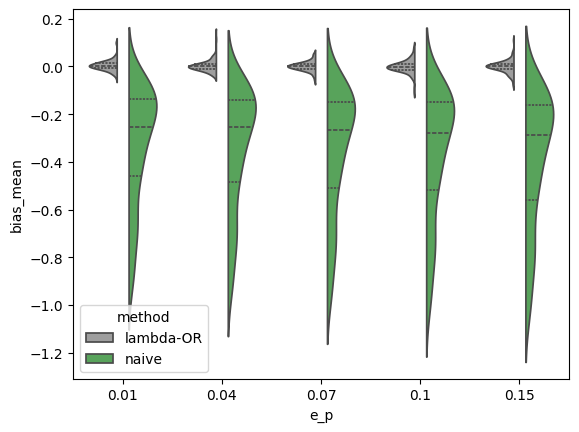

In [6]:
palette = ['#9e9e9e', '#4caf50']

sns.violinplot(
    x='e_p',
    y='bias_mean',
    data=df,
    hue='method',
    split=True,
    inner="quart",
    gap=.3,
    density_norm='count',
    palette=palette   # grey, green
)

In [ ]:
sns.violinplot(x='e_p',y='rmse',data=df, hue='method',split=True, inner="quart", gap=.3,density_norm='count')


In [ ]:
sns.violinplot(x='theta',y='rmse',data=df, hue='method',split=True, inner="quart", gap=.3,density_norm='count')


In [ ]:
sns.violinplot(x='theta',y='bias_mean',data=df, hue='method',split=True, inner="quart", gap=.3,density_norm='count')


In [ ]:
sns.violinplot(x='theta',y='cover_95',data=df, hue='method',split=True, inner="quart", gap=.3,density_norm='count')


In [ ]:
def long_to_wide_for_method(df_long, method_name,x_key,y_col):
    print(x_key,y_col)
    d = df_long[df_long['method'] == method_name].copy()

    # collect lists of y values per x bin
    grouped = d.groupby(x_key)[y_col].apply(list)

    # pad ragged lists into equal-length columns
    max_len = grouped.map(len).max()
    wide = pd.DataFrame({
        col: vals + [np.nan] * (max_len - len(vals))
        for col, vals in grouped.items()
    })

    # optional: sort columns numerically by the x label
    wide = wide.reindex(sorted(wide.columns, key=lambda s: float(s)), axis=1)

    return wide

In [ ]:
methods = sorted(df['method'].unique())

wide_A = long_to_wide_for_method(df, methods[0],'e_p','bias_mean')
wide_B = long_to_wide_for_method(df, methods[1],'e_p','bias_mean')

wide_A.to_csv("A.csv", index=False)
wide_B.to_csv("B.csv", index=False)

print("Method A:", methods[0], "-> violin_method_A.csv")
print("Method B:", methods[1], "-> violin_method_B.csv")
print("Columns (x levels):", list(wide_A.columns))

In [ ]:
!head A.csv

In [8]:
import pandas as pd

A = pd.read_csv("../tex/Figures/A.csv")
B = pd.read_csv("../tex/Figures/B.csv")

cols = list("ABCDE")  # 5 columns
A.columns = cols
B.columns = cols

A.to_csv("../tex/Figures/A_wide.dat", index=False)
B.to_csv("../tex/Figures/B_wide.dat", index=False)

print("Saved Figures/A_wide.dat and Figures/B_wide.dat")

Saved Figures/A_wide.dat and Figures/B_wide.dat


In [10]:
cat ../tex/Figures/A_wide.dat

A,B,C,D,E
0.044,-0.033,-0.037,0.003,-0.009
-0.022,0.028,-0.011,-0.011,0.111
-0.034,0.088,0.01,0.053,0.011
0.041,-0.015,-0.025,-0.109,-0.037
0.097,0.14,0.038,-0.088,-0.01
0.007,0.035,0.042,0.04,-0.052
0.028,-0.013,0.005,0.037,-0.078
-0.037,-0.007,0.013,0.042,-0.05
0.024,0.004,-0.053,0.029,-0.039
0.102,0.048,0.02,-0.054,0.034
0.024,0.004,-0.0,-0.01,0.024
-0.012,0.01,-0.006,-0.005,-0.071
-0.037,-0.019,0.025,-0.016,0.011
0.008,0.034,-0.012,-0.002,0.026
-0.013,-0.014,0.022,0.041,0.029
0.02,0.001,-0.007,0.015,0.006
-0.024,0.001,0.018,-0.038,-0.004
0.019,-0.007,0.004,-0.008,0.017
-0.001,-0.001,-0.012,-0.009,0.017
0.052,0.041,-0.015,0.029,0.022
0.01,-0.007,0.011,0.003,-0.04
0.012,0.001,0.002,-0.031,0.011
-0.005,0.015,-0.012,-0.007,0.009
0.014,-0.019,-0.003,0.031,-0.004
0.024,-0.017,-0.005,0.009,0.059
0.01,-0.003,0.018,0.062,-0.009
0.006,-0.006,-0.015,0.051,-0.008
0.001,0.062,0.046,0.025,-0.04
0.039,0.015,-0.003,0.073,-0.055
0.025,0.027,0.053,0.028,-0.002
0.002,0.002,-0.038,0.026,-0.002
-0.01,-